In [1]:
import pandas as pd
import numpy as np

import linearmodels as lm

In [2]:
df = pd.read_csv("data/processed/merged_data.csv")

In [3]:
df.columns.tolist()

['region',
 'wynagrodzenie',
 'rok',
 'bezrobotni_w_liczbie_ludności_w_wieku_produkcyjnym',
 'ogółem',
 'gimnazjalne,_podstawowe_i_niższe_ogółem_wartość_liczbowa',
 'gimnazjalne,_podstawowe_i_niższe_ogółem_wskaźnik_precyzji',
 'policealne_oraz_średnie_zawodowe/branżowe_ogółem_wartość_liczbowa',
 'policealne_oraz_średnie_zawodowe/branżowe_ogółem_wskaźnik_precyzji',
 'wyższe_ogółem_wartość_liczbowa',
 'wyższe_ogółem_wskaźnik_precyzji',
 'zasadnicze_zawodowe/branżowe_ogółem_wartość_liczbowa',
 'zasadnicze_zawodowe/branżowe_ogółem_wskaźnik_precyzji',
 'średnie_(łącznie_z_zasadniczym_zawodowym/branżowym_i_policealnym)_ogółem_wartość_liczbowa',
 'średnie_(łącznie_ze_średnim_zawodowym/branżowym_i_ogólnokształcącym)_ogółem_wartość_liczbowa',
 'średnie_ogólnokształcące_ogółem_wartość_liczbowa',
 'średnie_ogólnokształcące_ogółem_wskaźnik_precyzji',
 'średnie_zawodowe/branżowe_ogółem_wartość_liczbowa',
 'średnie_zawodowe/branżowe_ogółem_wskaźnik_precyzji',
 'saldo_migracji_ogółem',
 'wymeldowania

### 3. „Maksymalna liczba zmiennych = N/10"
To zasada kciuka dla regresji. Jeśli macie np. 380 powiatów × 10 lat = 3800 obserwacji, to możecie mieć do ~380 zmiennych. W praktyce przy danych panelowych liczy się liczba jednostek (N przekrojowy), więc przy 380 powiatach — bezpiecznie ~30–40 zmiennych objaśniających.

### 4. „Prosty współczynnik korelacji na danych pooled"
Zanim w ogóle budujecie model, sprawdźcie korelację każdej zmiennej z bezrobociem na całym zbiorze (bez rozróżnienia na panele):

In [4]:
"""
AUDYT DANYCH PANELOWYCH
=======================
Skrypt do sprawdzenia poprawności i jakości danych przed budową modelu panelowego.
Projekt: wpływ inwestycji / gęstości podmiotów na bezrobocie w Polsce.

Uruchomienie:
    pip install pandas numpy matplotlib seaborn
    python audyt_danych_panelowych.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# KONFIGURACJA — dostosuj do swojego pliku
# ─────────────────────────────────────────────
PLIK_DANYCH   = "data/processed/merged_data.csv"          # ścieżka do pliku (csv / xlsx)
SEP           = ","                  # separator CSV (zmień na ";" jeśli trzeba)
ZMIENNA_Y     = "bezrobotni_w_liczbie_ludności_w_wieku_produkcyjnym"
KOLUMNA_CZAS  = "rok"
KOLUMNA_ID    = "region"
PROG_NA       = 30                   # % braków powyżej którego zmienna jest podejrzana
# ─────────────────────────────────────────────


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# ══════════════════════════════════════════════
# 0. WCZYTANIE DANYCH
# ══════════════════════════════════════════════
print("=" * 60)
print("KROK 0 — Wczytanie danych")
print("=" * 60)

if PLIK_DANYCH.endswith(".xlsx"):
    df = pd.read_excel(PLIK_DANYCH)
else:
    df = pd.read_csv(PLIK_DANYCH, sep=SEP, low_memory=False)

print(f"  Wczytano: {df.shape[0]:,} wierszy × {df.shape[1]} kolumn")
print(f"  Kolumny: {list(df.columns)}\n")


KROK 0 — Wczytanie danych
  Wczytano: 459 wierszy × 38 kolumn
  Kolumny: ['region', 'wynagrodzenie', 'rok', 'bezrobotni_w_liczbie_ludności_w_wieku_produkcyjnym', 'ogółem', 'gimnazjalne,_podstawowe_i_niższe_ogółem_wartość_liczbowa', 'gimnazjalne,_podstawowe_i_niższe_ogółem_wskaźnik_precyzji', 'policealne_oraz_średnie_zawodowe/branżowe_ogółem_wartość_liczbowa', 'policealne_oraz_średnie_zawodowe/branżowe_ogółem_wskaźnik_precyzji', 'wyższe_ogółem_wartość_liczbowa', 'wyższe_ogółem_wskaźnik_precyzji', 'zasadnicze_zawodowe/branżowe_ogółem_wartość_liczbowa', 'zasadnicze_zawodowe/branżowe_ogółem_wskaźnik_precyzji', 'średnie_(łącznie_z_zasadniczym_zawodowym/branżowym_i_policealnym)_ogółem_wartość_liczbowa', 'średnie_(łącznie_ze_średnim_zawodowym/branżowym_i_ogólnokształcącym)_ogółem_wartość_liczbowa', 'średnie_ogólnokształcące_ogółem_wartość_liczbowa', 'średnie_ogólnokształcące_ogółem_wskaźnik_precyzji', 'średnie_zawodowe/branżowe_ogółem_wartość_liczbowa', 'średnie_zawodowe/branżowe_ogółem_wskaź

In [ ]:
# ══════════════════════════════════════════════
# 1. JEDNOSTKA OBSERWACJI
# ══════════════════════════════════════════════
print("=" * 60)
print("KROK 1 — Jednostka obserwacji (gmina / powiat / województwo?)")
print("=" * 60)

n_regionow  = df[KOLUMNA_ID].nunique()
n_lat       = df[KOLUMNA_CZAS].nunique()
lata        = sorted(df[KOLUMNA_CZAS].unique())
n_obs       = len(df)

print(f"  Unikalnych regionów  : {n_regionow}")
print(f"  Unikalnych lat       : {n_lat}  → {lata[0]}–{lata[-1]}")
print(f"  Łączna liczba obs.   : {n_obs:,}")

if   n_regionow <= 17:
    poziom = "WOJEWÓDZTWA (16 + ewentualnie ogółem Polska)"
elif n_regionow <= 400:
    poziom = "POWIATY (~380 w Polsce)"
else:
    poziom = "GMINY (~2500 w Polsce)"

print(f"\n  ➤ Prawdopodobny poziom agregacji: {poziom}")
print(f"  ➤ Maksymalna bezpieczna liczba zmiennych w modelu: ~{n_regionow // 10}\n")

# Czy panel jest zbalansowany?
obs_per_region = df.groupby(KOLUMNA_ID)[KOLUMNA_CZAS].count()
if obs_per_region.nunique() == 1:
    print("  ✔ Panel ZBALANSOWANY — każdy region ma tyle samo obserwacji.")
else:
    print("  ⚠ Panel NIEZBALANSOWANY — różna liczba lat na region:")
    print(obs_per_region.value_counts().to_string())
print()


KROK 1 — Jednostka obserwacji (gmina / powiat / województwo?)
  Unikalnych regionów  : 17
  Unikalnych lat       : 27  → 1999–2025
  Łączna liczba obs.   : 459

  ➤ Prawdopodobny poziom agregacji: WOJEWÓDZTWA (16 + ewentualnie ogółem Polska)
  ➤ Maksymalna bezpieczna liczba zmiennych w modelu: ~1

  ✔ Panel ZBALANSOWANY — każdy region ma tyle samo obserwacji.



In [ ]:
# ══════════════════════════════════════════════
# 2. AUDYT BRAKÓW DANYCH
# ══════════════════════════════════════════════
print("=" * 60)
print("KROK 2 — Braki danych (NA) w każdej kolumnie")
print("=" * 60)

braki = (
    df.isnull().sum()
      .reset_index()
      .rename(columns={"index": "zmienna", 0: "n_NA"})
)
braki["pct_NA"] = (braki["n_NA"] / len(df) * 100).round(1)
braki = braki.sort_values("pct_NA", ascending=False)

# Podział na grupy
ok       = braki[braki["pct_NA"] == 0]
ostrzez  = braki[(braki["pct_NA"] > 0) & (braki["pct_NA"] < PROG_NA)]
problem  = braki[braki["pct_NA"] >= PROG_NA]

print(f"\n  ✔ Kompletne zmienne (0% NA)   : {len(ok)}")
print(f"  ⚠ Częściowe braki (<{PROG_NA}% NA)   : {len(ostrzez)}")
print(f"  ✖ Problematyczne (≥{PROG_NA}% NA)   : {len(problem)}")

if not problem.empty:
    print(f"\n  Zmienne z ≥{PROG_NA}% braków (rozważ usunięcie):")
    print(problem[["zmienna", "n_NA", "pct_NA"]].to_string(index=False))

if not ostrzez.empty:
    print(f"\n  Zmienne z częściowymi brakami:")
    print(ostrzez[["zmienna", "n_NA", "pct_NA"]].to_string(index=False))



KROK 2 — Braki danych (NA) w każdej kolumnie

  ✔ Kompletne zmienne (0% NA)   : 2
  ⚠ Częściowe braki (<30% NA)   : 18
  ✖ Problematyczne (≥30% NA)   : 18

  Zmienne z ≥30% braków (rozważ usunięcie):
                                                                                     zmienna  n_NA  pct_NA
                                                                               wynagrodzenie   283    61.7
                                                                       uczelnie niepubliczne   283    61.7
                                                                          uczelnie publiczne   283    61.7
                                          bezrobotni_w_liczbie_ludności_w_wieku_produkcyjnym   272    59.3
                                    gimnazjalne,_podstawowe_i_niższe_ogółem_wartość_liczbowa   187    40.7
                                   gimnazjalne,_podstawowe_i_niższe_ogółem_wskaźnik_precyzji   187    40.7
średnie_(łącznie_ze_średnim_zawodowym/branżowym_i_o

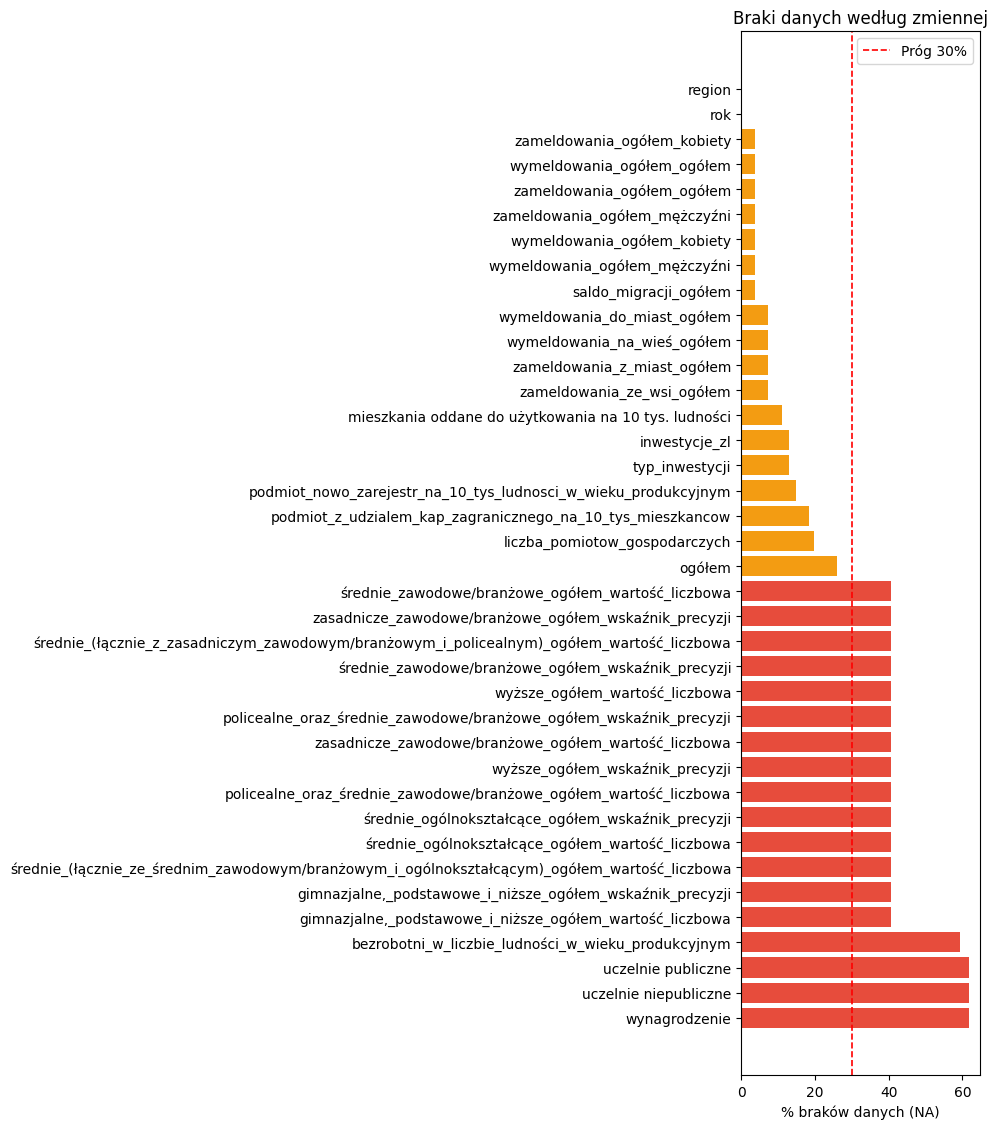

In [ ]:

# Wykres
fig, ax = plt.subplots(figsize=(10, max(4, len(braki) * 0.3)))
kolory = ["#e74c3c" if p >= PROG_NA else "#f39c12" if p > 0 else "#2ecc71"
          for p in braki["pct_NA"]]
ax.barh(braki["zmienna"], braki["pct_NA"], color=kolory)
ax.axvline(PROG_NA, color="red", linestyle="--", linewidth=1.2,
           label=f"Próg {PROG_NA}%")
ax.set_xlabel("% braków danych (NA)")
ax.set_title("Braki danych według zmiennej")
ax.legend()
plt.tight_layout()
plt.show()



In [ ]:

# ══════════════════════════════════════════════
# 3. TYPY DANYCH I KOLUMNY KATEGORYCZNE
# ══════════════════════════════════════════════
print("=" * 60)
print("KROK 3 — Typy danych i zmienne kategoryczne")
print("=" * 60)

typy = df.dtypes.reset_index().rename(columns={"index": "zmienna", 0: "dtype"})
typy["n_unikalnych"] = [df[c].nunique() for c in typy["zmienna"]]
typy["przyklad"]     = [str(df[c].dropna().iloc[0]) if df[c].dropna().shape[0] > 0
                        else "—" for c in typy["zmienna"]]

print("\n  Typy zmiennych:")
print(typy.to_string(index=False))

# Ostrzeżenie o kolumnach numerycznych zapisanych jako string
num_jako_str = [c for c in df.columns
                if df[c].dtype == object
                and c not in [KOLUMNA_ID, "typ_inwestycji"]]
if num_jako_str:
    print(f"\n  ⚠ Możliwe zmienne numeryczne zapisane jako tekst: {num_jako_str}")
    print("    Sprawdź czy nie ma przecinków zamiast kropek jako separatora dziesiętnego.\n")

KROK 3 — Typy danych i zmienne kategoryczne

  Typy zmiennych:
                                                                                     zmienna   dtype  n_unikalnych     przyklad
                                                                                      region  object            17 DOLNOŚLĄSKIE
                                                                               wynagrodzenie  object           176      4042,86
                                                                                         rok   int64            27         1999
                                          bezrobotni_w_liczbie_ludności_w_wieku_produkcyjnym float64            36          2.6
                                                                                      ogółem float64           339      86092.0
                                    gimnazjalne,_podstawowe_i_niższe_ogółem_wartość_liczbowa  object           108           17
                                   gimnaz

KROK 4 — Zmienna zależna: bezrobotni_w_liczbie_ludności_w_wieku_produkcyjnym

  Liczba obs.     : 187
  Braki           : 272 (59.3%)
  Min / Max       : 0.60 / 4.60
  Średnia / Mediana: 2.00 / 1.90
  Odch. std.      : 0.82
  Skośność        : 0.66 ✔ OK


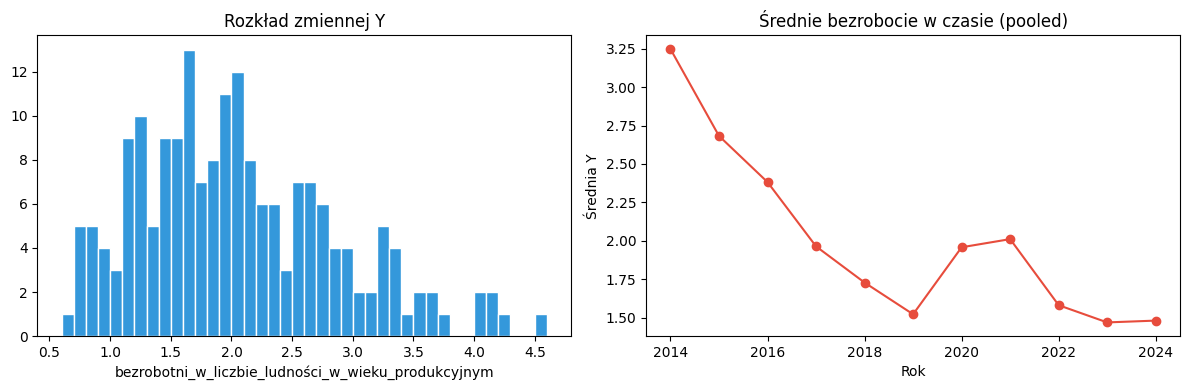

In [ ]:
# ══════════════════════════════════════════════
# 4. STATYSTYKI OPISOWE ZMIENNEJ ZALEŻNEJ
# ══════════════════════════════════════════════
print("=" * 60)
print(f"KROK 4 — Zmienna zależna: {ZMIENNA_Y}")
print("=" * 60)

if ZMIENNA_Y in df.columns:
    y = pd.to_numeric(df[ZMIENNA_Y], errors="coerce")
    print(f"\n  Liczba obs.     : {y.notna().sum():,}")
    print(f"  Braki           : {y.isna().sum()} ({y.isna().mean()*100:.1f}%)")
    print(f"  Min / Max       : {y.min():.2f} / {y.max():.2f}")
    print(f"  Średnia / Mediana: {y.mean():.2f} / {y.median():.2f}")
    print(f"  Odch. std.      : {y.std():.2f}")

    # Skośność — ważna dla OLS
    skewness = y.skew()
    print(f"  Skośność        : {skewness:.2f}", end=" ")
    if abs(skewness) > 1:
        print("⚠ Wysoka skośność — rozważ transformację log()")
    else:
        print("✔ OK")

    # Wykres: rozkład Y
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(y.dropna(), bins=40, color="#3498db", edgecolor="white")
    axes[0].set_title("Rozkład zmiennej Y")
    axes[0].set_xlabel(ZMIENNA_Y)
    axes[1].plot(df.groupby(KOLUMNA_CZAS)[ZMIENNA_Y].mean()
                   .reset_index().set_index(KOLUMNA_CZAS),
                 marker="o", color="#e74c3c")
    axes[1].set_title("Średnie bezrobocie w czasie (pooled)")
    axes[1].set_xlabel("Rok")
    axes[1].set_ylabel("Średnia Y")
    plt.tight_layout()
    plt.show()
else:
    print(f"  ✖ Nie znaleziono kolumny '{ZMIENNA_Y}' — sprawdź nazwę!")
print()

KROK 5 — Korelacje z bezrobociem (dane pooled)
  (wskazówka opiekuna: jeśli niskie → trudno zbudować dobry model)

                                                   zmienna  korelacja_z_Y         ocena
                                             inwestycje_zl      -0.493663 ✔ umiarkowana
      mieszkania oddane do użytkowania na 10 tys. ludności      -0.464204 ✔ umiarkowana
                                        uczelnie publiczne      -0.332471 ✔ umiarkowana
                                     saldo_migracji_ogółem      -0.263039       ~ słaba
                                     uczelnie niepubliczne      -0.249741       ~ słaba
podmiot_z_udzialem_kap_zagranicznego_na_10_tys_mieszkancow      -0.242384       ~ słaba
                                                    ogółem       0.104319       ~ słaba
                               zameldowania_z_miast_ogółem      -0.098717        ✖ brak
                             zameldowania_ogółem_mężczyźni      -0.090575        ✖ brak
     

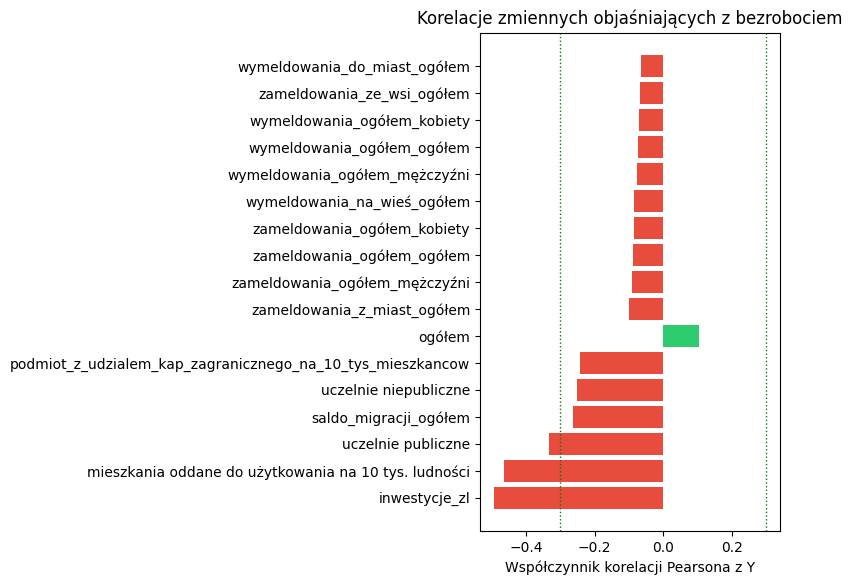


  ── Kluczowe determinanty (wybór opiekuna) ──
  inwestycje_zl: r = -0.494
  podmiot_nowo_zarejestr_na_10_tys_ludnosci_w_wieku_produkcyjnym: ✖ brak w danych



In [ ]:
# ══════════════════════════════════════════════
# 5. KORELACJE Z ZMIENNĄ ZALEŻNĄ (dane pooled)
# ══════════════════════════════════════════════
print("=" * 60)
print("KROK 5 — Korelacje z bezrobociem (dane pooled)")
print("=" * 60)
print("  (wskazówka opiekuna: jeśli niskie → trudno zbudować dobry model)\n")

# Tylko kolumny numeryczne, bez Y i kolumn technicznych
cols_num = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in [ZMIENNA_Y, KOLUMNA_CZAS]]

if ZMIENNA_Y in df.columns and cols_num:
    df_num = df[cols_num + [ZMIENNA_Y]].apply(pd.to_numeric, errors="coerce")
    corr = (df_num.corr()[ZMIENNA_Y]
                  .drop(ZMIENNA_Y)
                  .sort_values(key=abs, ascending=False)
                  .reset_index())
    corr.columns = ["zmienna", "korelacja_z_Y"]
    corr["ocena"] = corr["korelacja_z_Y"].apply(
        lambda r: "✔✔ silna"   if abs(r) >= 0.5 else
                  "✔ umiarkowana" if abs(r) >= 0.3 else
                  "~ słaba"    if abs(r) >= 0.1 else
                  "✖ brak")
    print(corr.to_string(index=False))

    # Wykres korelacji
    fig, ax = plt.subplots(figsize=(8, max(4, len(corr) * 0.35)))
    kolory_corr = ["#e74c3c" if r < 0 else "#2ecc71" for r in corr["korelacja_z_Y"]]
    ax.barh(corr["zmienna"], corr["korelacja_z_Y"], color=kolory_corr)
    ax.axvline(0.3,  color="green", linestyle=":", linewidth=1)
    ax.axvline(-0.3, color="green", linestyle=":", linewidth=1)
    ax.set_xlabel("Współczynnik korelacji Pearsona z Y")
    ax.set_title("Korelacje zmiennych objaśniających z bezrobociem")
    plt.tight_layout()
    plt.show()

    # Kluczowe zmienne opiekuna
    klucz_inv = "inwestycje_zl"
    klucz_pod = "podmiot_nowo_zarejestr_na_10_tys_ludnosci_w_wieku_produkcyjnym"
    print("\n  ── Kluczowe determinanty (wybór opiekuna) ──")
    for zn in [klucz_inv, klucz_pod]:
        if zn in corr["zmienna"].values:
            r = corr.loc[corr["zmienna"] == zn, "korelacja_z_Y"].values[0]
            print(f"  {zn}: r = {r:.3f}")
        else:
            print(f"  {zn}: ✖ brak w danych")
print()




KROK 6 — Multikolinearność między zmiennymi objaśniającymi

  ⚠ Pary zmiennych silnie skorelowanych (|r| > 0.85) — ryzyko multikolinearności:
    wymeldowania_ogółem_kobiety ↔ wymeldowania_ogółem_mężczyźni  : r = 1.0
    wymeldowania_ogółem_kobiety ↔ wymeldowania_ogółem_ogółem  : r = 1.0
    wymeldowania_ogółem_mężczyźni ↔ wymeldowania_ogółem_ogółem  : r = 1.0
    zameldowania_ogółem_kobiety ↔ zameldowania_ogółem_mężczyźni  : r = 1.0
    zameldowania_ogółem_kobiety ↔ zameldowania_ogółem_ogółem  : r = 1.0
    zameldowania_ogółem_mężczyźni ↔ zameldowania_ogółem_ogółem  : r = 1.0
    wymeldowania_do_miast_ogółem ↔ wymeldowania_ogółem_kobiety  : r = 0.999
    wymeldowania_do_miast_ogółem ↔ wymeldowania_ogółem_mężczyźni  : r = 0.999
    wymeldowania_do_miast_ogółem ↔ wymeldowania_ogółem_ogółem  : r = 0.999
    wymeldowania_ogółem_mężczyźni ↔ zameldowania_ogółem_mężczyźni  : r = 0.999
    wymeldowania_ogółem_ogółem ↔ zameldowania_ogółem_mężczyźni  : r = 0.999
    zameldowania_ogółem_kobiety 

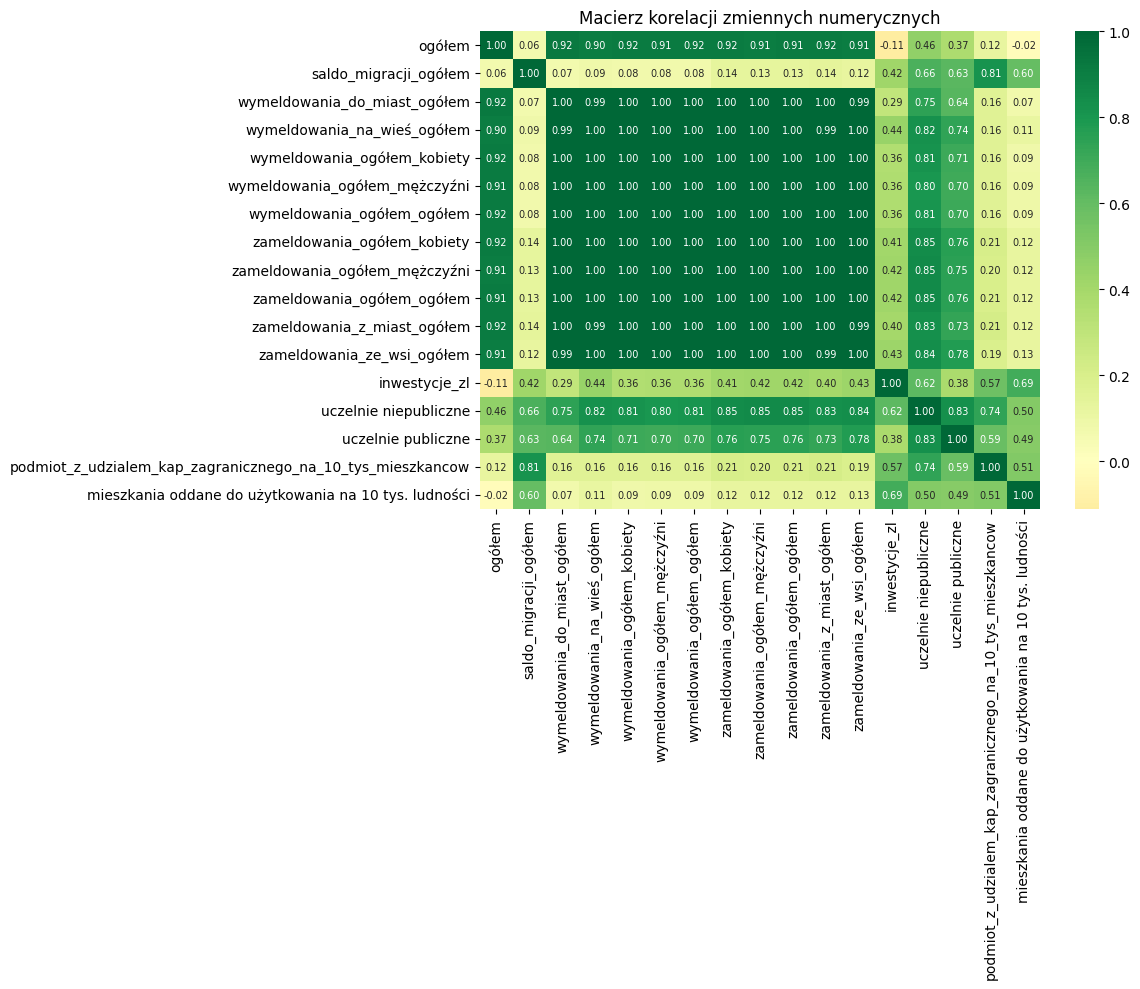


  → Zapisano: audyt_04_heatmapa.png



In [ ]:
# ══════════════════════════════════════════════
# 6. MACIERZ KORELACJI (multikolinearność)
# ══════════════════════════════════════════════
print("=" * 60)
print("KROK 6 — Multikolinearność między zmiennymi objaśniającymi")
print("=" * 60)

if len(cols_num) > 1:
    corr_matrix = df_num[cols_num].corr()

    # Pary z bardzo wysoką korelacją (|r| > 0.85)
    wysokie = []
    for i in range(len(cols_num)):
        for j in range(i+1, len(cols_num)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.85:
                wysokie.append((cols_num[i], cols_num[j], round(r, 3)))

    if wysokie:
        print(f"\n  ⚠ Pary zmiennych silnie skorelowanych (|r| > 0.85) — ryzyko multikolinearności:")
        for z1, z2, r in sorted(wysokie, key=lambda x: -abs(x[2])):
            print(f"    {z1} ↔ {z2}  : r = {r}")
    else:
        print("  ✔ Brak skrajnej multikolinearności między zmiennymi.")

    # Heatmapa (tylko jeśli mało zmiennych)
    if len(cols_num) <= 20:
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
                    center=0, ax=ax, annot_kws={"size": 7})
        ax.set_title("Macierz korelacji zmiennych numerycznych")
        plt.tight_layout()
        plt.show()
        print("\n  → Zapisano: audyt_04_heatmapa.png")
print()



In [ ]:

# ══════════════════════════════════════════════
# 7. PODSUMOWANIE I REKOMENDACJE
# ══════════════════════════════════════════════
print("=" * 60)
print("KROK 7 — PODSUMOWANIE DLA OPIEKUNA")
print("=" * 60)

print(f"""
  Dane:
    • Poziom agregacji     : {poziom}
    • Liczba regionów (N)  : {n_regionow}
    • Liczba lat (T)       : {n_lat}  ({lata[0]}–{lata[-1]})
    • Łączna liczba obs.   : {n_obs:,}
    • Maks. zmiennych w modelu: ~{n_regionow // 10}

  Jakość danych:
    • Kompletne zmienne    : {len(ok)} z {len(df.columns)}
    • Zmienne z ≥{PROG_NA}% NA  : {len(problem)} (do usunięcia lub imputation)

  Wykresy zapisane:
    • audyt_01_braki_danych.png
    • audyt_02_zmienna_Y.png
    • audyt_03_korelacje.png
    • audyt_04_heatmapa.png  (jeśli ≤20 zmiennych num.)
""")

print("=" * 60)
print("Audyt zakończony.")
print("=" * 60)

KROK 7 — PODSUMOWANIE DLA OPIEKUNA

  Dane:
    • Poziom agregacji     : WOJEWÓDZTWA (16 + ewentualnie ogółem Polska)
    • Liczba regionów (N)  : 17
    • Liczba lat (T)       : 27  (1999–2025)
    • Łączna liczba obs.   : 459
    • Maks. zmiennych w modelu: ~1

  Jakość danych:
    • Kompletne zmienne    : 2 z 38
    • Zmienne z ≥30% NA  : 18 (do usunięcia lub imputation)

  Wykresy zapisane:
    • audyt_01_braki_danych.png
    • audyt_02_zmienna_Y.png
    • audyt_03_korelacje.png
    • audyt_04_heatmapa.png  (jeśli ≤20 zmiennych num.)

Audyt zakończony.
